In [ ]:
!pip uninstall -y scikit-learn scikeras keras tensorflow
!pip install scikit-learn==1.5.2 scikeras==0.13.0 tensorflow==2.19.0 keras==3.9.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
Found existing installation: keras 3.9.2
Uninstalling keras-3.9.2:
  Successfully uninstalled keras-3.9.2
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached tensorflow-2.19.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)
Using cached tensorflo

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV


In [ ]:

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)


Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


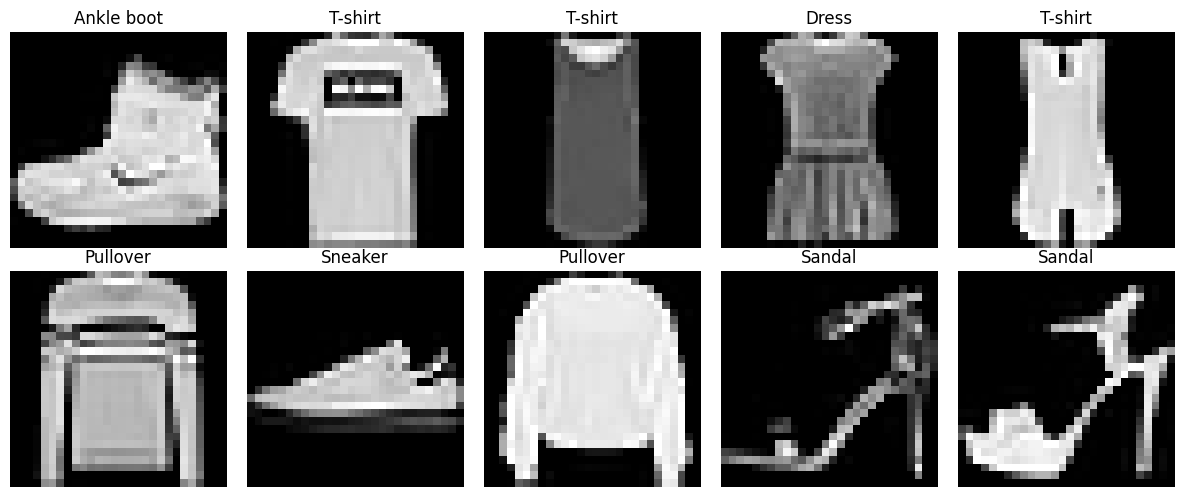

In [ ]:

# Display 10 sample images
classes=['T-shirt','Trouser','Pullover','Dress','Coat',
         'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(classes[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.savefig("sample_images.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()


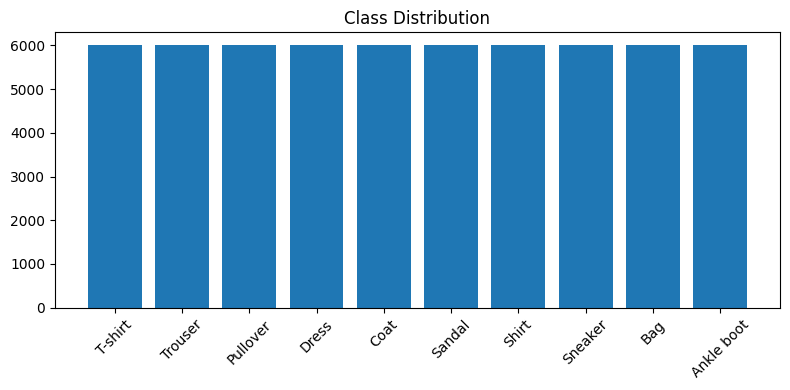

In [ ]:

# Class distribution
plt.figure(figsize=(8,4))
plt.bar(range(10), np.bincount(y_train))
plt.xticks(range(10), classes, rotation=45)
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("class_distribution.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()



In [ ]:

# Shapes before preprocessing
print("Before:", X_train.shape, X_test.shape)

X_train_flat = X_train.reshape(-1,784).astype("float32")/255.0
X_test_flat = X_test.reshape(-1,784).astype("float32")/255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

print("After:", X_train_flat.shape, X_test_flat.shape)


Before: (60000, 28, 28) (10000, 28, 28)
After: (60000, 784) (10000, 784)


In [ ]:

# Baseline Model
def baseline_model():
    model=Sequential([
        Input(shape=(784,)),
        Dense(128,activation='relu'),
        Dense(64,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model=baseline_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

start=time.time()
history=model.fit(
    X_train_flat,y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_time=time.time()-start


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7680 - loss: 0.6664 - val_accuracy: 0.8521 - val_loss: 0.4091
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8598 - loss: 0.3889 - val_accuracy: 0.8504 - val_loss: 0.4129
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8711 - loss: 0.3501 - val_accuracy: 0.8686 - val_loss: 0.3643
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8834 - loss: 0.3190 - val_accuracy: 0.8742 - val_loss: 0.3431
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8912 - loss: 0.2934 - val_accuracy: 0.8811 - val_loss: 0.3314
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8948 - loss: 0.2814 - val_accuracy: 0.8827 - val_loss: 0.3326
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9002 - loss: 0.2663 - val_accuracy: 0.8837 - val_loss: 0.3289
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9022 - loss: 0.2572 

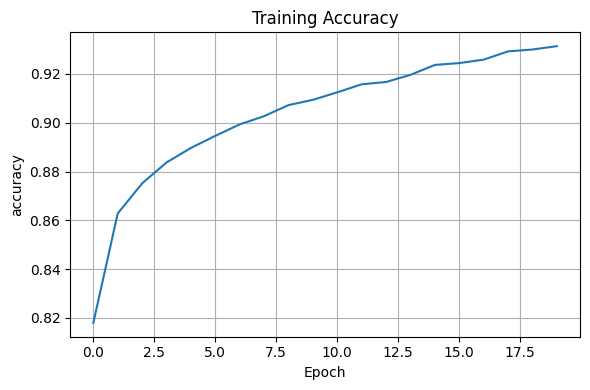

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig("training_accuracy.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()


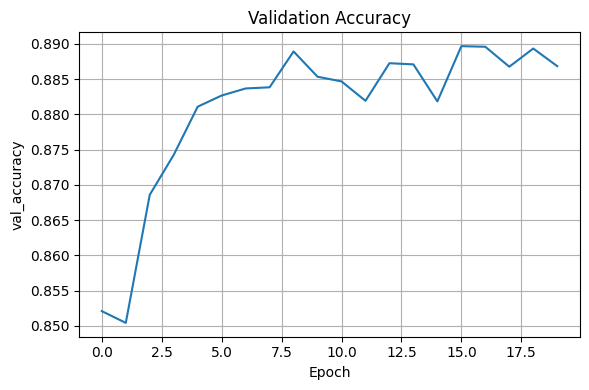

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(history.history['val_accuracy'])
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('val_accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig("validation_accuracy.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()


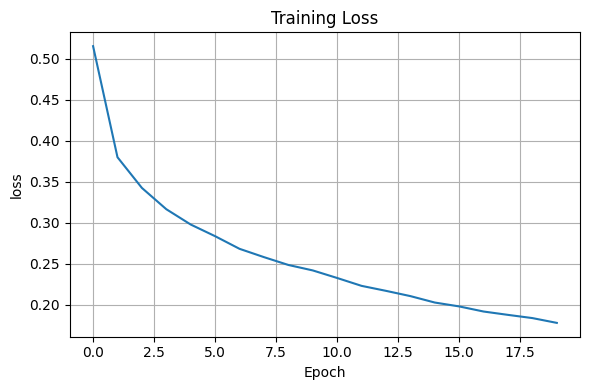

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()


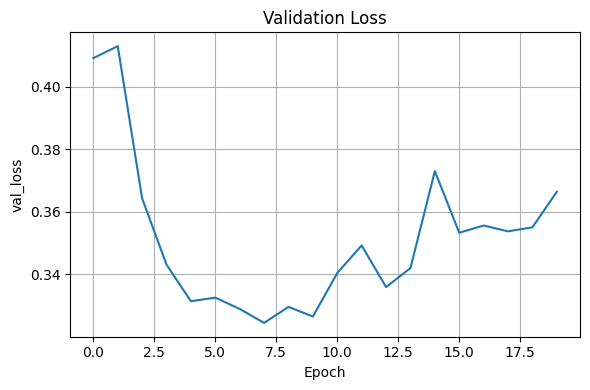

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(history.history['val_loss'])
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('val_loss')
plt.grid(True)
plt.tight_layout()
plt.savefig("validation_loss.eps", format="eps", dpi=200, bbox_inches="tight")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8758
Precision: 0.8786748956866346
Recall: 0.8758
F1: 0.8763529419090317


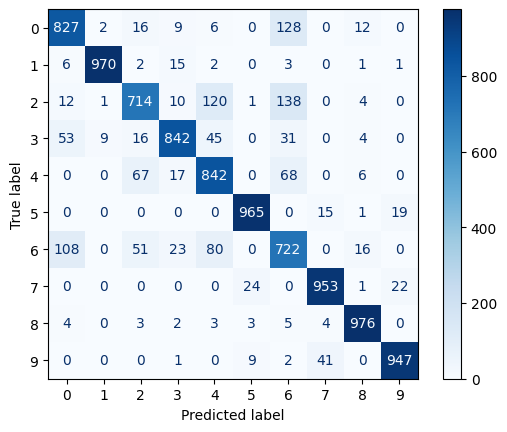

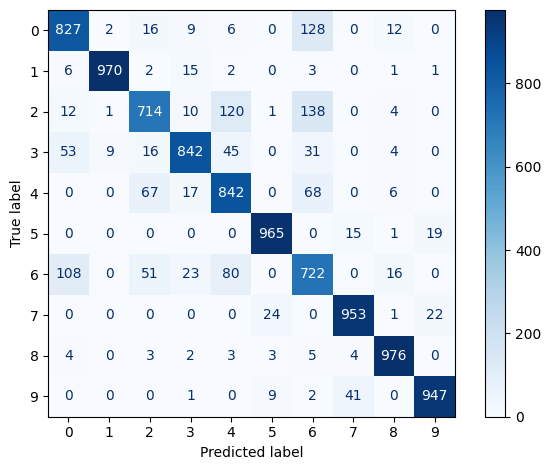

              precision    recall  f1-score   support

     T-shirt       0.82      0.83      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.71      0.76      1000
       Dress       0.92      0.84      0.88      1000
        Coat       0.77      0.84      0.80      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.66      0.72      0.69      1000
     Sneaker       0.94      0.95      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:

pred_prob=model.predict(X_test_flat)
pred=np.argmax(pred_prob,axis=1)

baseline_acc=accuracy_score(y_test,pred)
baseline_prec=precision_score(y_test,pred,average='weighted')
baseline_rec=recall_score(y_test,pred,average='weighted')
baseline_f1=f1_score(y_test,pred,average='weighted')

print("Accuracy:",baseline_acc)
print("Precision:",baseline_prec)
print("Recall:",baseline_rec)
print("F1:",baseline_f1)

cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

print(classification_report(y_test,pred,target_names=classes))


In [ ]:

# Hyperparameter Optimization
def create_model(hidden_layers=2, hidden_neurons=128,
                 learning_rate=0.001,
                 optimizer='adam',
                 activation='relu',
                 dropout_rate=0.0):

    model=Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons,activation=activation))
        if dropout_rate>0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10,activation='softmax'))

    opt={
        'adam':tf.keras.optimizers.Adam(learning_rate),
        'sgd':tf.keras.optimizers.SGD(learning_rate),
        'rmsprop':tf.keras.optimizers.RMSprop(learning_rate)
    }[optimizer.lower()]

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

clf=KerasClassifier(model=create_model, verbose=0)

param_dist={
'model__hidden_layers':[1,2,3],
'model__hidden_neurons':[32,64,128,256],
'model__learning_rate':[0.1,0.01,0.001],
'model__optimizer':['adam','sgd','rmsprop'],
'model__activation':['relu','tanh','sigmoid'],
'model__dropout_rate':[0.0,0.2,0.5],
'batch_size':[16,32,64,128],
'epochs':[10,20,30]
}

search=RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=3,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

search.fit(X_train_flat,y_train_cat)
print(search.best_params_)
print(search.best_score_)


{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}
0.8881500000000001


              precision    recall  f1-score   support

     T-shirt       0.84      0.85      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.75      0.85      0.80      1000
       Dress       0.91      0.85      0.88      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.75      0.66      0.70      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



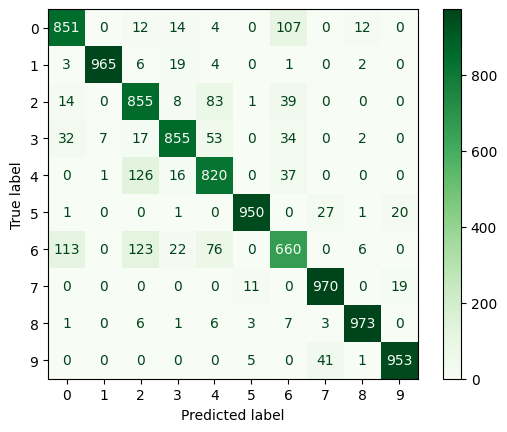

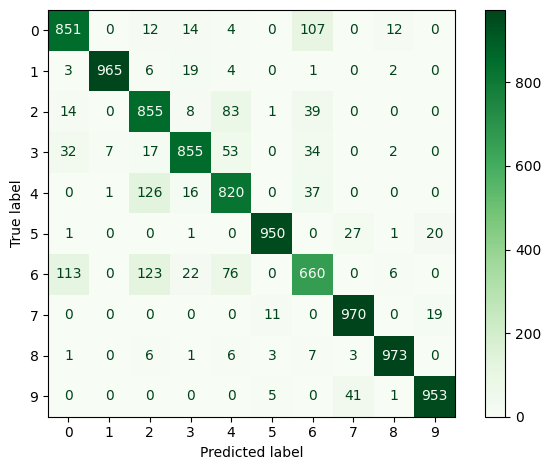

In [ ]:

best=search.best_estimator_

start=time.time()
best.fit(X_train_flat,y_train_cat)
optimized_time=time.time()-start

opt_pred=best.predict(X_test_flat)
opt_pred = np.argmax(opt_pred, axis=1)

opt_acc=accuracy_score(y_test,opt_pred)
opt_prec=precision_score(y_test,opt_pred,average='weighted')
opt_rec=recall_score(y_test,opt_pred,average='weighted')
opt_f1=f1_score(y_test,opt_pred,average='weighted')

print(classification_report(y_test,opt_pred,target_names=classes))

cm=confusion_matrix(y_test,opt_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Greens')
ConfusionMatrixDisplay(cm).plot(cmap="Greens")

plt.tight_layout()
plt.savefig("optimized_confusion_matrix.eps",
            format="eps",
            dpi=200,
            bbox_inches="tight")

plt.show()


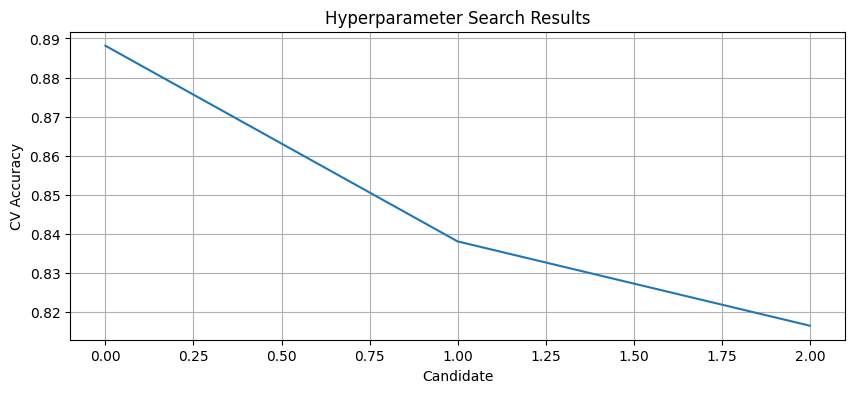

In [ ]:

# Hyperparameter Search Results
results=pd.DataFrame(search.cv_results_)
results=results.sort_values("mean_test_score",ascending=False)

plt.figure(figsize=(10,4))
plt.plot(results["mean_test_score"].values)
plt.title("Hyperparameter Search Results")
plt.xlabel("Candidate")
plt.ylabel("CV Accuracy")
plt.grid(True)
plt.show()


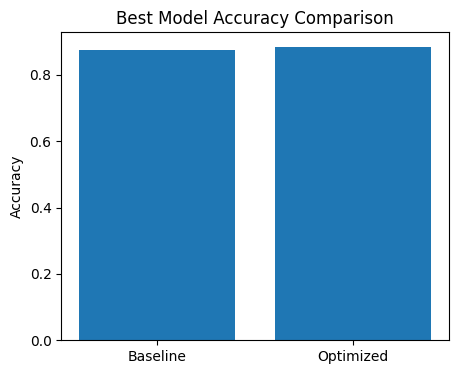

          Metric    Baseline   Optimized
0       Accuracy    0.875800    0.884000
1      Precision    0.878675    0.884909
2         Recall    0.875800    0.884000
3       F1-score    0.876353    0.884044
4  Training Time  144.785310  212.134536

Best Hyperparameters
{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}
Cross Validation Accuracy: 0.8881500000000001
Testing Accuracy: 0.884


In [ ]:

# Baseline vs Optimized Accuracy
plt.figure(figsize=(5,4))
plt.bar(["Baseline","Optimized"],[baseline_acc,opt_acc])
plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")
plt.show()

comparison=pd.DataFrame({
'Metric':['Accuracy','Precision','Recall','F1-score','Training Time'],
'Baseline':[baseline_acc,baseline_prec,baseline_rec,baseline_f1,baseline_time],
'Optimized':[opt_acc,opt_prec,opt_rec,opt_f1,optimized_time]
})

print(comparison)

print("\nBest Hyperparameters")
print(search.best_params_)
print("Cross Validation Accuracy:",search.best_score_)
print("Testing Accuracy:",opt_acc)
